# Benchmarking scikit-learn Random Forest vs. Yggdrasil Decision Forests (YDF) Gradient Boosted Trees Learner on the CDC Diabetes Health Indicators dataset.

In [16]:
import json
import os
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from box import Box

warnings.filterwarnings("ignore")

## Configuration

In [2]:
CLASS_IMBALANCE_STRATEGY = "class_weight"  # options: None, "class_weight"
LABEL_COL = "Diabetes_binary"
TEST_SIZE = 0.20

## UTILITY FUNCTIONS

In [3]:
def load_data(path: str) -> pd.DataFrame:
    """Load the FULL CDC Diabetes Health Indicators dataset 
    """
    df = pd.read_csv(path)
    assert LABEL_COL in df.columns, f"Expected label column '{LABEL_COL}' not found."
    return df


def preprocess(df: pd.DataFrame):
    """Identical preprocessing pipeline for BOTH models 
    """
    X = df.drop(columns=[LABEL_COL])
    y = df[LABEL_COL].astype(int)
    return X, y


def balanced_class_weight_map(y_train: pd.Series) -> dict:
    """Compute balanced class weights the same way scikit-learn's
    class_weight='balanced' does: n_samples / (n_classes * count_per_class).
    Returns {class_value: weight}.
    """
    counts = y_train.value_counts()
    n_samples = len(y_train)
    n_classes = len(counts)
    return {cls: n_samples / (n_classes * count) for cls, count in counts.items()}


def balanced_sample_weights(y: pd.Series) -> pd.Series:
    """Map balanced_class_weight_map() over every row to get a per-row
    sample-weight Series, aligned to y's index.

    This is passed to YDF as a sample-weight COLUMN via the `weights=`
    parameter (supported across YDF versions), rather than a class-weight
    DICT via `class_weights=` (only present in some YDF releases and not
    others -- passing it unconditionally caused
    "TypeError: unexpected keyword argument 'class_weights'" on older/newer
    installs). Using an explicit per-row weight column sidesteps that
    version dependency entirely while producing the same effective
    weighting: rows of the minority class get a higher weight, rows of the
    majority class get a lower weight, computed identically to
    scikit-learn's class_weight='balanced'.
    """
    weight_map = balanced_class_weight_map(y)
    return y.map(weight_map)

## MODEL, EVALUTATION AND SERIALIZATION FUNCTIONS

In [4]:
def make_rf_model(random_state: int) -> RandomForestClassifier:
    """Random Forest with explicit, reported hyperparameters.
    """
    kwargs = dict(n_estimators=100, random_state=random_state)
    if CLASS_IMBALANCE_STRATEGY == "class_weight":
        kwargs["class_weight"] = "balanced"
    return RandomForestClassifier(**kwargs)


def evaluate_predictions(y_true, y_pred, y_score) -> dict:
    """Compute the full metric set, including AUC-ROC and confusion
    matrix (leakage/plausibility check)."""
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc_roc": roc_auc_score(y_true, y_score),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def serialized_size_kb(obj, path: Path, kind: str) -> float:
    """Measure ACTUAL on-disk serialized model size in kB
    kind: 'sklearn' uses joblib.dump; 'ydf' uses the model's native save().
    """
    if kind == "sklearn":
        joblib.dump(obj, path)
        size_bytes = os.path.getsize(path)
    elif kind == "ydf":
        # YDF's save() writes a directory of files; sum their sizes.
        obj.save(str(path))
        size_bytes = sum(f.stat().st_size for f in Path(path).rglob("*") if f.is_file())
    else:
        raise ValueError(kind)
    return size_bytes / 1024.0

## TRIAL RUN AND TOP FEATURES FUNCTIONS

In [5]:
def run_trial(trial_no: int, X, y, outdir: Path) -> dict:
    """Run one trial: train + evaluate RF and YDF-GBTL on an IDENTICAL
    split and IDENTICAL preprocessing, varying only random_state."""
    import ydf  # imported here so the script still runs --skip-ydf without the dependency installed

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=trial_no, stratify=y
    )

    # --- Identical preprocessing for both models (comment #2) ---
    scaler = StandardScaler()
    col_trans = ColumnTransformer(
        transformers=[("scaler", scaler, ["BMI"])], remainder="passthrough"
    )
    X_train_scaled = pd.DataFrame(
        col_trans.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        col_trans.transform(X_test), columns=X_test.columns, index=X_test.index
    )

    # ---------------- Random Forest ----------------
    rf = make_rf_model(random_state=trial_no)
    t0 = time.perf_counter()
    rf.fit(X_train_scaled, y_train)
    rf_train_time = time.perf_counter() - t0

    rf_pred = rf.predict(X_test_scaled)
    rf_score = rf.predict_proba(X_test_scaled)[:, 1]
    rf_metrics = evaluate_predictions(y_test, rf_pred, rf_score)
    rf_metrics["train_time_s"] = rf_train_time
    rf_model_path = outdir / f"_tmp_rf_trial{trial_no}.joblib"
    rf_metrics["model_size_kb"] = serialized_size_kb(rf, rf_model_path, "sklearn")
    rf_model_path.unlink(missing_ok=True)

    # ---------------- YDF Gradient Boosted Trees ----------------
    train_ydf = X_train_scaled.copy()
    train_ydf[LABEL_COL] = y_train.values
    test_ydf = X_test_scaled.copy()
    test_ydf[LABEL_COL] = y_test.values

    ydf_kwargs = dict(label=LABEL_COL)
    if CLASS_IMBALANCE_STRATEGY == "class_weight":
        # Attach a per-row sample-weight column (balanced, same formula as
        # scikit-learn's class_weight="balanced") and point YDF's weights=
        # parameter at it. This works across YDF versions, unlike the
        # class_weights=dict parameter which is not present in every release.
        weight_col = "_sample_weight"
        train_ydf[weight_col] = balanced_sample_weights(y_train).values
        ydf_kwargs["weights"] = weight_col

    t0 = time.perf_counter()
    ydf_model = ydf.GradientBoostedTreesLearner(**ydf_kwargs).train(
        train_ydf, verbose=0
    )
    ydf_train_time = time.perf_counter() - t0

    ydf_test_no_label = test_ydf.drop(columns=[LABEL_COL])
    ydf_score = np.asarray(ydf_model.predict(ydf_test_no_label)).ravel()
    ydf_pred = (ydf_score >= 0.5).astype(int)
    ydf_metrics = evaluate_predictions(y_test, ydf_pred, ydf_score)
    ydf_metrics["train_time_s"] = ydf_train_time
    ydf_model_dir = outdir / f"_tmp_ydf_trial{trial_no}"
    ydf_metrics["model_size_kb"] = serialized_size_kb(ydf_model, ydf_model_dir, "ydf")

    return {"trial": trial_no, "rf": rf_metrics, "ydf": ydf_metrics}


def top_feature_importances(X, y, n: int, top_k: int = 10) -> pd.DataFrame:
    """Fit one RF and one YDF model on a single identically-preprocessed
    split to extract the top-k predictor variables for BOTH models
    (feeds the corrected Table 4)."""
    import ydf

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=0, stratify=y
    )
    scaler = StandardScaler()
    col_trans = ColumnTransformer(
        transformers=[("scaler", scaler, ["BMI"])], remainder="passthrough"
    )
    X_train_scaled = pd.DataFrame(
        col_trans.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )

    rf = make_rf_model(random_state=0)
    rf.fit(X_train_scaled, y_train)
    rf_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(
        ascending=False
    )

    train_ydf = X_train_scaled.copy()
    train_ydf[LABEL_COL] = y_train.values
    ydf_kwargs = dict(label=LABEL_COL)
    if CLASS_IMBALANCE_STRATEGY == "class_weight":
        weight_col = "_sample_weight"
        train_ydf[weight_col] = balanced_sample_weights(y_train).values
        ydf_kwargs["weights"] = weight_col
    ydf_model = ydf.GradientBoostedTreesLearner(**ydf_kwargs).train(
        train_ydf, verbose=0
    )
    ydf_va = ydf_model.variable_importances().get("SUM_SCORE", [])
    # Each entry is a (score, feature_name) tuple.
    ydf_importance = pd.Series({name: score for score, name in ydf_va})
    ydf_importance = ydf_importance.sort_values(ascending=False)

    out = pd.DataFrame(
        {
            "RF_rank": range(1, min(top_k, len(rf_importance)) + 1),
            "RF_feature": rf_importance.index[:top_k],
            "RF_importance": rf_importance.values[:top_k],
        }
    )
    out2 = pd.DataFrame(
        {
            "YDF_rank": range(1, min(top_k, len(ydf_importance)) + 1),
            "YDF_feature": ydf_importance.index[:top_k],
            "YDF_importance": ydf_importance.values[:top_k],
        }
    )
    return pd.concat([out, out2], axis=1)

## PAIRED TTEST FUNCTION

In [6]:
def paired_ttest(rf_vals: np.ndarray, ydf_vals: np.ndarray):
    """Paired-samples t-test (fixes comment #7). Falls back to Wilcoxon
    if the normality assumption is clearly violated (Shapiro p < 0.05 on
    the paired differences), reported alongside for transparency."""
    diffs = ydf_vals - rf_vals
    t_stat, t_p = stats.ttest_rel(ydf_vals, rf_vals)
    try:
        shapiro_p = stats.shapiro(diffs).pvalue
    except Exception:
        shapiro_p = np.nan
    w_stat, w_p = (np.nan, np.nan)
    if len(diffs) >= 5:
        try:
            w_stat, w_p = stats.wilcoxon(ydf_vals, rf_vals)
        except Exception:
            pass
    return {
        "t_stat": t_stat,
        "t_pvalue": t_p,
        "shapiro_pvalue_on_diffs": shapiro_p,
        "wilcoxon_stat": w_stat,
        "wilcoxon_pvalue": w_p,
    }

## MAIN FUNCTION

In [24]:
def main():

    args = Box(
        {
            "data": "data.csv",  # "Path to diabetes_binary_health_indicators_BRFSS2015.csv"
            "trials": 10,  # Number of trials
            "outdir": "results",  # Output folder for the results
            "top-k": 10,  # Top-k predictor variables to report
        }
    )

    outdir = Path(args.outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    print(f"Loading data from {args.data} ...")
    df = load_data(args.data)
    n_total = len(df)
    prevalence = df[LABEL_COL].mean()
    print(f"Full dataset: N={n_total}, positive-class prevalence={prevalence:.4f}")

    X, y = preprocess(df)

    print(f"Running {args.trials} paired trials (RF vs YDF-GBTL) ...")
    trial_results = []
    for trial_no in range(args.trials):
        print(f"  Trial {trial_no} ...")
        result = run_trial(trial_no, X, y, outdir)
        trial_results.append(result)

    # ---- Table 1: RF per-trial metrics ----
    rf_rows = []
    for r in trial_results:
        row = {"trial": r["trial"], **r["rf"]}
        rf_rows.append(row)
    table1 = pd.DataFrame(rf_rows)
    table1.to_csv(outdir / "table1_rf_trials.csv", index=False)

    # ---- Table 2: YDF per-trial metrics ----
    ydf_rows = []
    for r in trial_results:
        row = {"trial": r["trial"], **r["ydf"]}
        ydf_rows.append(row)
    table2 = pd.DataFrame(ydf_rows)
    table2.to_csv(outdir / "table2_ydf_trials.csv", index=False)

    # ---- Table 3: paired comparison summary ----
    metrics_to_compare = [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc_roc",
        "train_time_s",
        "model_size_kb",
    ]
    summary_rows = []
    for m in metrics_to_compare:
        rf_vals = table1[m].to_numpy()
        ydf_vals = table2[m].to_numpy()
        test_result = paired_ttest(rf_vals, ydf_vals)
        summary_rows.append(
            {
                "metric": m,
                "rf_mean": rf_vals.mean(),
                "rf_sd": rf_vals.std(ddof=1),
                "ydf_mean": ydf_vals.mean(),
                "ydf_sd": ydf_vals.std(ddof=1),
                **test_result,
            }
        )
    table3 = pd.DataFrame(summary_rows)
    table3.to_csv(outdir / "table3_paired_comparison.csv", index=False)

    # ---- Table 4: top predictor variables for both models ----
    print("Fitting single models for variable-importance comparison ...")
    table4 = top_feature_importances(X, y, n=n_total, top_k=args.top_k)
    table4.to_csv(outdir / "table4_variable_importance.csv", index=False)

    # ---- Dataset / summary metadata for the Abstract & Methodology ----
    summary = {
        "dataset_path": str(args.data),
        "n_total_rows": int(n_total),
        "n_features": int(X.shape[1]),
        "positive_class_prevalence": float(prevalence),
        "n_trials": args.trials,
        "test_size": TEST_SIZE,
        "class_imbalance_strategy": CLASS_IMBALANCE_STRATEGY,
        "rf_hyperparameters": "n_estimators=100, class_weight='balanced' if CLASS_IMBALANCE_STRATEGY else default, all else scikit-learn defaults (see make_rf_model)",
        "ydf_learner": "GradientBoostedTreesLearner, library defaults, weights=<balanced per-row sample-weight column, computed per-trial> if CLASS_IMBALANCE_STRATEGY else default",
    }
    with open(outdir / "run_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    print("\nDone. Results written to:", outdir.resolve())
    print(" - table1_rf_trials.csv")
    print(" - table2_ydf_trials.csv")
    print(" - table3_paired_comparison.csv")
    print(" - table4_variable_importance.csv")
    print(" - run_summary.json")

In [25]:
main()

Loading data from data.csv ...
Full dataset: N=253680, positive-class prevalence=0.1393
Running 10 paired trials (RF vs YDF-GBTL) ...
  Trial 0 ...


max_vocab_count = -1 for column Diabetes_binary, the dictionary will not be pruned by size.
"goss_alpha" set but "sampling_method" not equal to "GOSS".
"goss_beta" set but "sampling_method" not equal to "GOSS".
"selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
Data spec:
Number of records: 202944
Number of columns: 23

Number of columns by type:
	NUMERICAL: 22 (95.6522%)
	CATEGORICAL: 1 (4.34783%)

Columns:

NUMERICAL: 22 (95.6522%)
	1: "_sample_weight" NUMERICAL mean:1 min:0.580945 max:3.5885 sd:1.0415 dtype:DTYPE_FLOAT64
	2: "HighBP" NUMERICAL mean:-3.34888e-09 min:-2.48041 max:10.5425 sd:1 dtype:DTYPE_FLOAT64
	3: "HighChol" NUMERICAL mean:0.428754 min:0 max:1 sd:0.494898 dtype:DTYPE_FLOAT64
	4: "CholCheck" NUMERICAL mean:0.424841 min:0 max:1 sd:0.494319 dtype:DTYPE_FLOAT64
	5: "BMI" NUMERICAL mean:0.962837 min:0 max:1 sd:0.189161 dtype:DTYPE_FLOAT64
	6: "Smoker" NUMERICAL mean:0.442876 min:0 max:1 sd:0.496726 dtype:DTYPE_FLOAT64
	7: "Stroke" NUMERIC

  Trial 1 ...


max_vocab_count = -1 for column Diabetes_binary, the dictionary will not be pruned by size.
"goss_alpha" set but "sampling_method" not equal to "GOSS".
"goss_beta" set but "sampling_method" not equal to "GOSS".
"selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
Data spec:
Number of records: 202944
Number of columns: 23

Number of columns by type:
	NUMERICAL: 22 (95.6522%)
	CATEGORICAL: 1 (4.34783%)

Columns:

NUMERICAL: 22 (95.6522%)
	1: "_sample_weight" NUMERICAL mean:1 min:0.580945 max:3.5885 sd:1.0415 dtype:DTYPE_FLOAT64
	2: "HighBP" NUMERICAL mean:3.46843e-09 min:-2.48217 max:10.5491 sd:1 dtype:DTYPE_FLOAT64
	3: "HighChol" NUMERICAL mean:0.428719 min:0 max:1 sd:0.494893 dtype:DTYPE_FLOAT64
	4: "CholCheck" NUMERICAL mean:0.425206 min:0 max:1 sd:0.494374 dtype:DTYPE_FLOAT64
	5: "BMI" NUMERICAL mean:0.962517 min:0 max:1 sd:0.189943 dtype:DTYPE_FLOAT64
	6: "Smoker" NUMERICAL mean:0.443147 min:0 max:1 sd:0.496757 dtype:DTYPE_FLOAT64
	7: "Stroke" NUMERICA

  Trial 2 ...


...

max_vocab_count = -1 for column Diabetes_binary, the dictionary will not be pruned by size.
"goss_alpha" set but "sampling_method" not equal to "GOSS".
"goss_beta" set but "sampling_method" not equal to "GOSS".
"selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
Data spec:
Number of records: 202944
Number of columns: 23

Number of columns by type:
	NUMERICAL: 22 (95.6522%)
	CATEGORICAL: 1 (4.34783%)

Columns:

NUMERICAL: 22 (95.6522%)
	1: "_sample_weight" NUMERICAL mean:1 min:0.580945 max:3.5885 sd:1.0415 dtype:DTYPE_FLOAT64
	2: "HighBP" NUMERICAL mean:-5.54083e-10 min:-2.47749 max:10.5347 sd:1 dtype:DTYPE_FLOAT64
	3: "HighChol" NUMERICAL mean:0.429084 min:0 max:1 sd:0.494945 dtype:DTYPE_FLOAT64
	4: "CholCheck" NUMERICAL mean:0.423861 min:0 max:1 sd:0.494169 dtype:DTYPE_FLOAT64
	5: "BMI" NUMERICAL mean:0.96266 min:0 max:1 sd:0.189594 dtype:DTYPE_FLOAT64
	6: "Smoker" NUMERICAL mean:0.442945 min:0 max:1 sd:0.496734 dtype:DTYPE_FLOAT64
	7: "Stroke" NUMERICA

Fitting single models for variable-importance comparison ...


max_vocab_count = -1 for column Diabetes_binary, the dictionary will not be pruned by size.
"goss_alpha" set but "sampling_method" not equal to "GOSS".
"goss_beta" set but "sampling_method" not equal to "GOSS".
"selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
Data spec:
Number of records: 202944
Number of columns: 23

Number of columns by type:
	NUMERICAL: 22 (95.6522%)
	CATEGORICAL: 1 (4.34783%)

Columns:

NUMERICAL: 22 (95.6522%)
	1: "_sample_weight" NUMERICAL mean:1 min:0.580945 max:3.5885 sd:1.0415 dtype:DTYPE_FLOAT64
	2: "HighBP" NUMERICAL mean:-3.34888e-09 min:-2.48041 max:10.5425 sd:1 dtype:DTYPE_FLOAT64
	3: "HighChol" NUMERICAL mean:0.428754 min:0 max:1 sd:0.494898 dtype:DTYPE_FLOAT64
	4: "CholCheck" NUMERICAL mean:0.424841 min:0 max:1 sd:0.494319 dtype:DTYPE_FLOAT64
	5: "BMI" NUMERICAL mean:0.962837 min:0 max:1 sd:0.189161 dtype:DTYPE_FLOAT64
	6: "Smoker" NUMERICAL mean:0.442876 min:0 max:1 sd:0.496726 dtype:DTYPE_FLOAT64
	7: "Stroke" NUMERIC


Done. Results written to: /home/tejas/MLProjects/ydf-vs-rf-study/results
 - table1_rf_trials.csv
 - table2_ydf_trials.csv
 - table3_paired_comparison.csv
 - table4_variable_importance.csv
 - run_summary.json


Early stop of the training because the validation loss does not decrease anymore. Best valid-loss: 1.00509
Truncates the model to 91 tree(s) i.e. 91  iteration(s).
Final model num-trees:91 valid-loss:1.005090 valid-accuracy:0.748612


## VISUALIZATION OF RESULTS

In [37]:

rf_results = pd.read_csv("results/table1_rf_trials.csv",index_col="trial")
ydf_results = pd.read_csv(
    "results/table2_ydf_trials.csv", index_col="trial"
)
ptt_results = pd.read_csv(
    "results/table3_paired_comparison.csv"
)

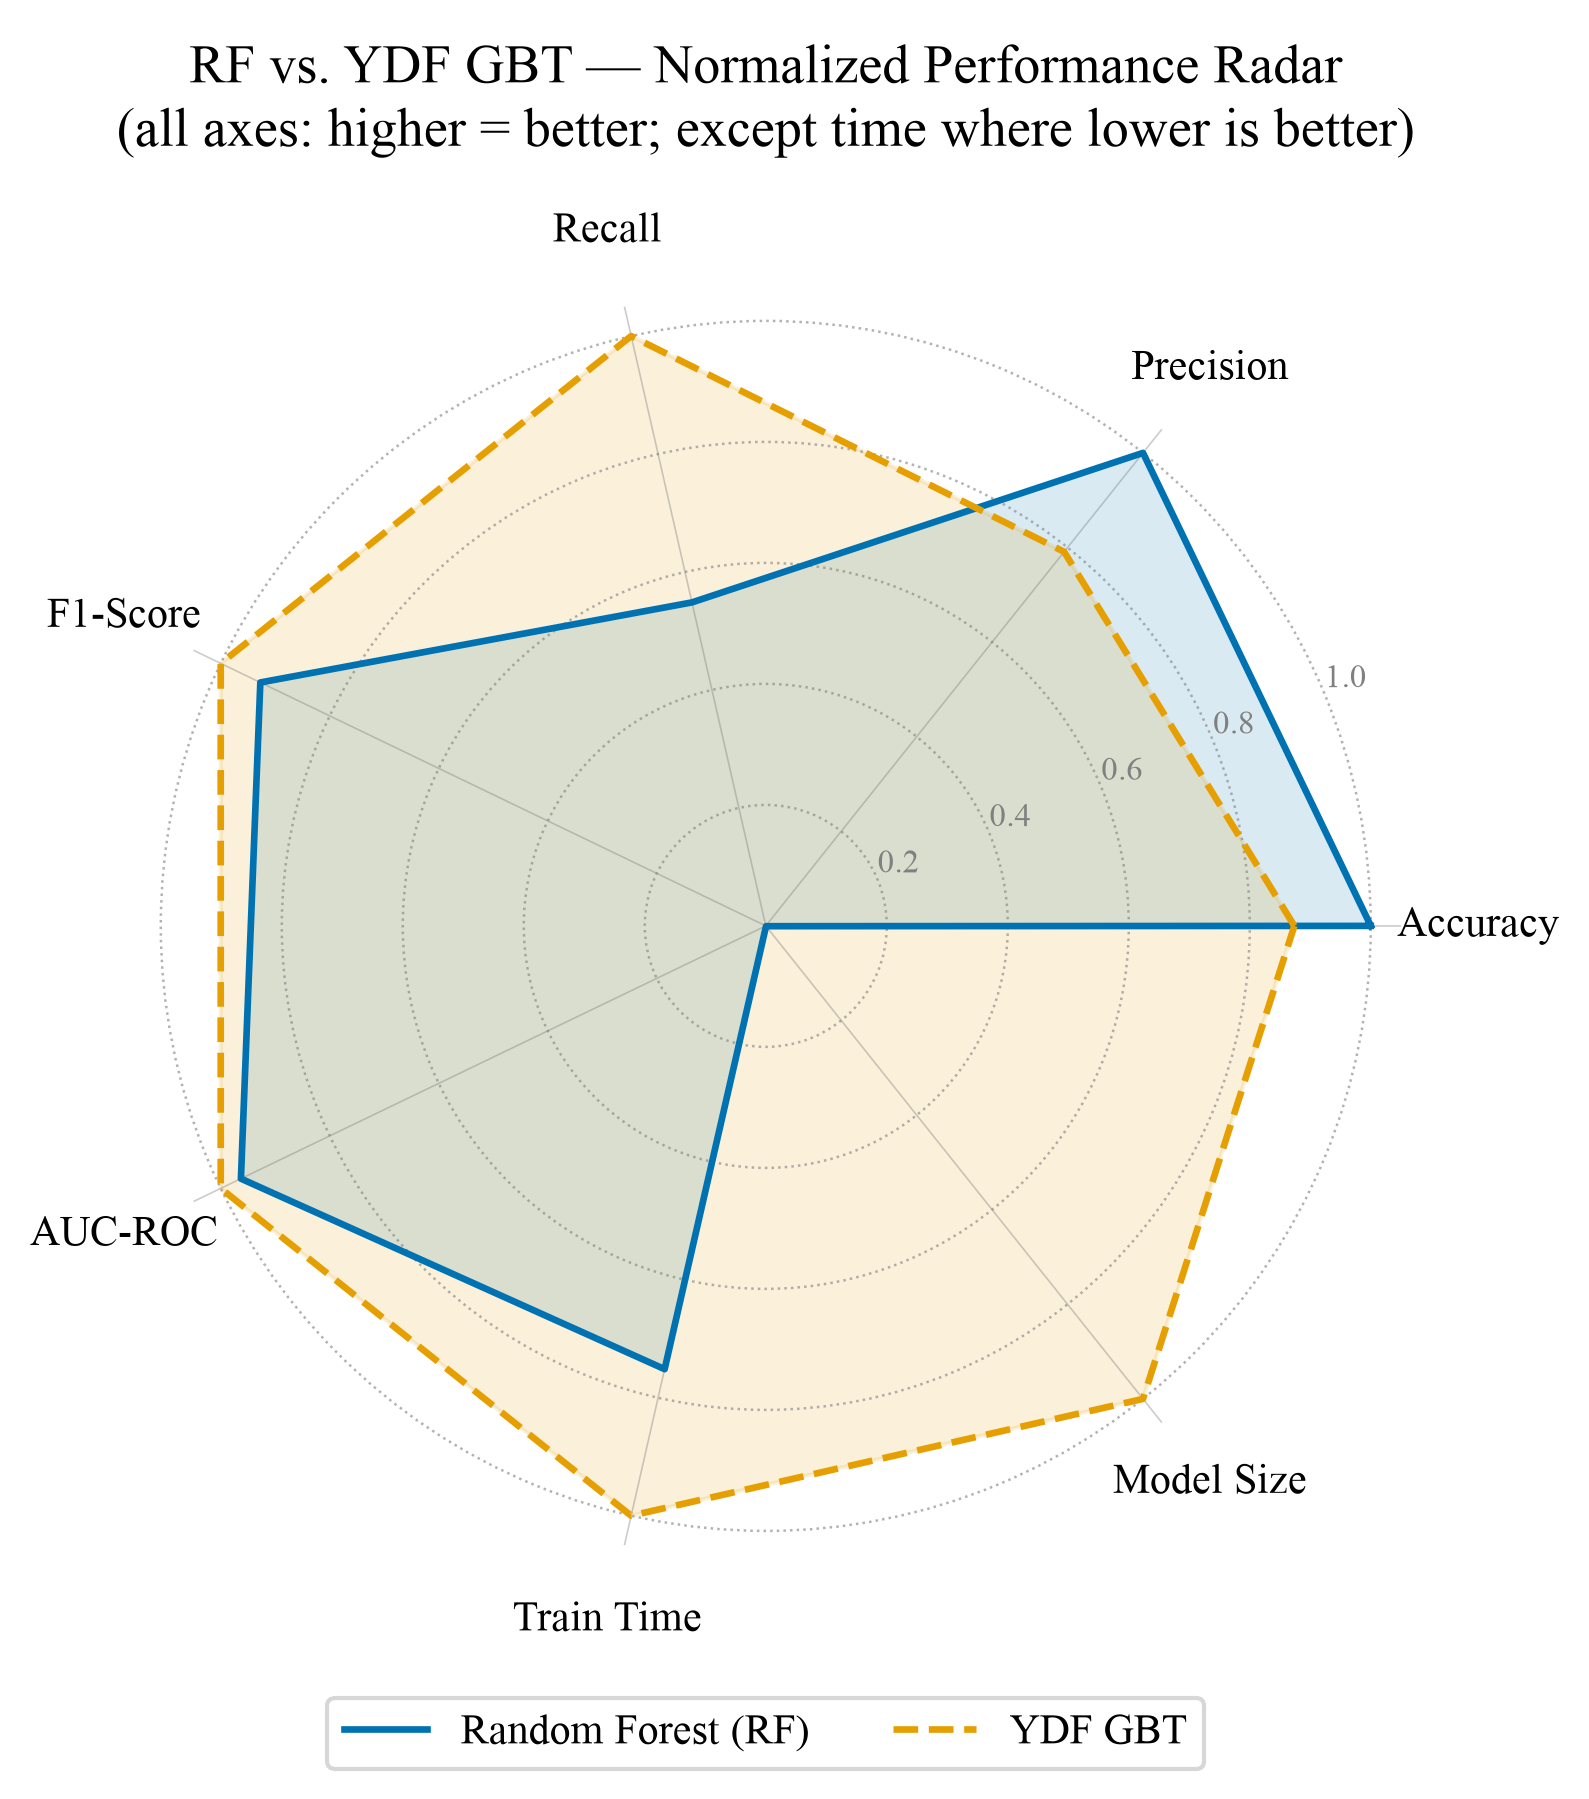

Saved → visualization/radar_chart.pdf  &  visualization/radar_chart.png


In [44]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

# ── Publication style ──────────────────────────────────────────────────────────
mpl.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":   9,
    "legend.fontsize":  10,
    "figure.dpi":       300,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})

# ── Data ───────────────────────────────────────────────────────────────────────
radar_metrics = ["accuracy", "precision", "recall", "f1", "auc_roc", "train_time_s", "model_size_kb"]
radar_labels  = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "Train Time", "Model Size"]

rf_mean  = rf_results[radar_metrics].mean()
ydf_mean = ydf_results[radar_metrics].mean()

benefit_metrics = {"accuracy", "precision", "recall", "f1", "auc_roc"}

rf_norm, ydf_norm = [], []
for m in radar_metrics:
    if m in benefit_metrics:
        best = max(rf_mean[m], ydf_mean[m])
        rf_norm.append(rf_mean[m]  / best if best else 0.0)
        ydf_norm.append(ydf_mean[m] / best if best else 0.0)
    else:
        best = min(rf_mean[m], ydf_mean[m])
        rf_norm.append(best / rf_mean[m]  if rf_mean[m]  else 0.0)
        ydf_norm.append(best / ydf_mean[m] if ydf_mean[m] else 0.0)

N      = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]
rf_vals_plot  = rf_norm  + rf_norm[:1]
ydf_vals_plot = ydf_norm + ydf_norm[:1]

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw={"polar": True})

# Colorblind-safe palette (Wong 2011)
COLOR_RF  = "#0072B2"   # blue
COLOR_YDF = "#E69F00"   # amber

ax.plot(angles, rf_vals_plot,  color=COLOR_RF,  linewidth=1.6,
        linestyle="-",  label="Random Forest (RF)")
ax.fill(angles, rf_vals_plot,  color=COLOR_RF,  alpha=0.15)

ax.plot(angles, ydf_vals_plot, color=COLOR_YDF, linewidth=1.6,
        linestyle="--", label="YDF GBT")
ax.fill(angles, ydf_vals_plot, color=COLOR_YDF, alpha=0.15)

# ── Grid & ticks ───────────────────────────────────────────────────────────────
yticks = [0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(yticks)
ax.set_yticklabels([f"{v:.1f}" for v in yticks], color="grey", size=8)
ax.set_ylim(0, 1.05)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=10)

# Push spoke labels outward so they don't overlap the polygon
ax.tick_params(axis="x", pad=8)

# Subtle concentric grid
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, color="grey", alpha=0.6)
ax.xaxis.grid(True, linestyle="-",  linewidth=0.4, color="grey", alpha=0.4)
ax.spines["polar"].set_visible(False)

# ── Legend & title ─────────────────────────────────────────────────────────────
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=True,
    framealpha=0.9,
    edgecolor="lightgrey",
)
ax.set_title(
    "RF vs. YDF GBT — Normalized Performance Radar\n"
    "(all axes: higher = better; except time where lower is better)",
    pad=16,
    linespacing=1.4,
)

# ── Save & show ────────────────────────────────────────────────────────────────
out_path = Path("visualization/radar_chart.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(out_path)
fig.savefig(out_path.with_suffix(".png"))
plt.show()
print(f"Saved → {out_path}  &  {out_path.with_suffix('.png')}")

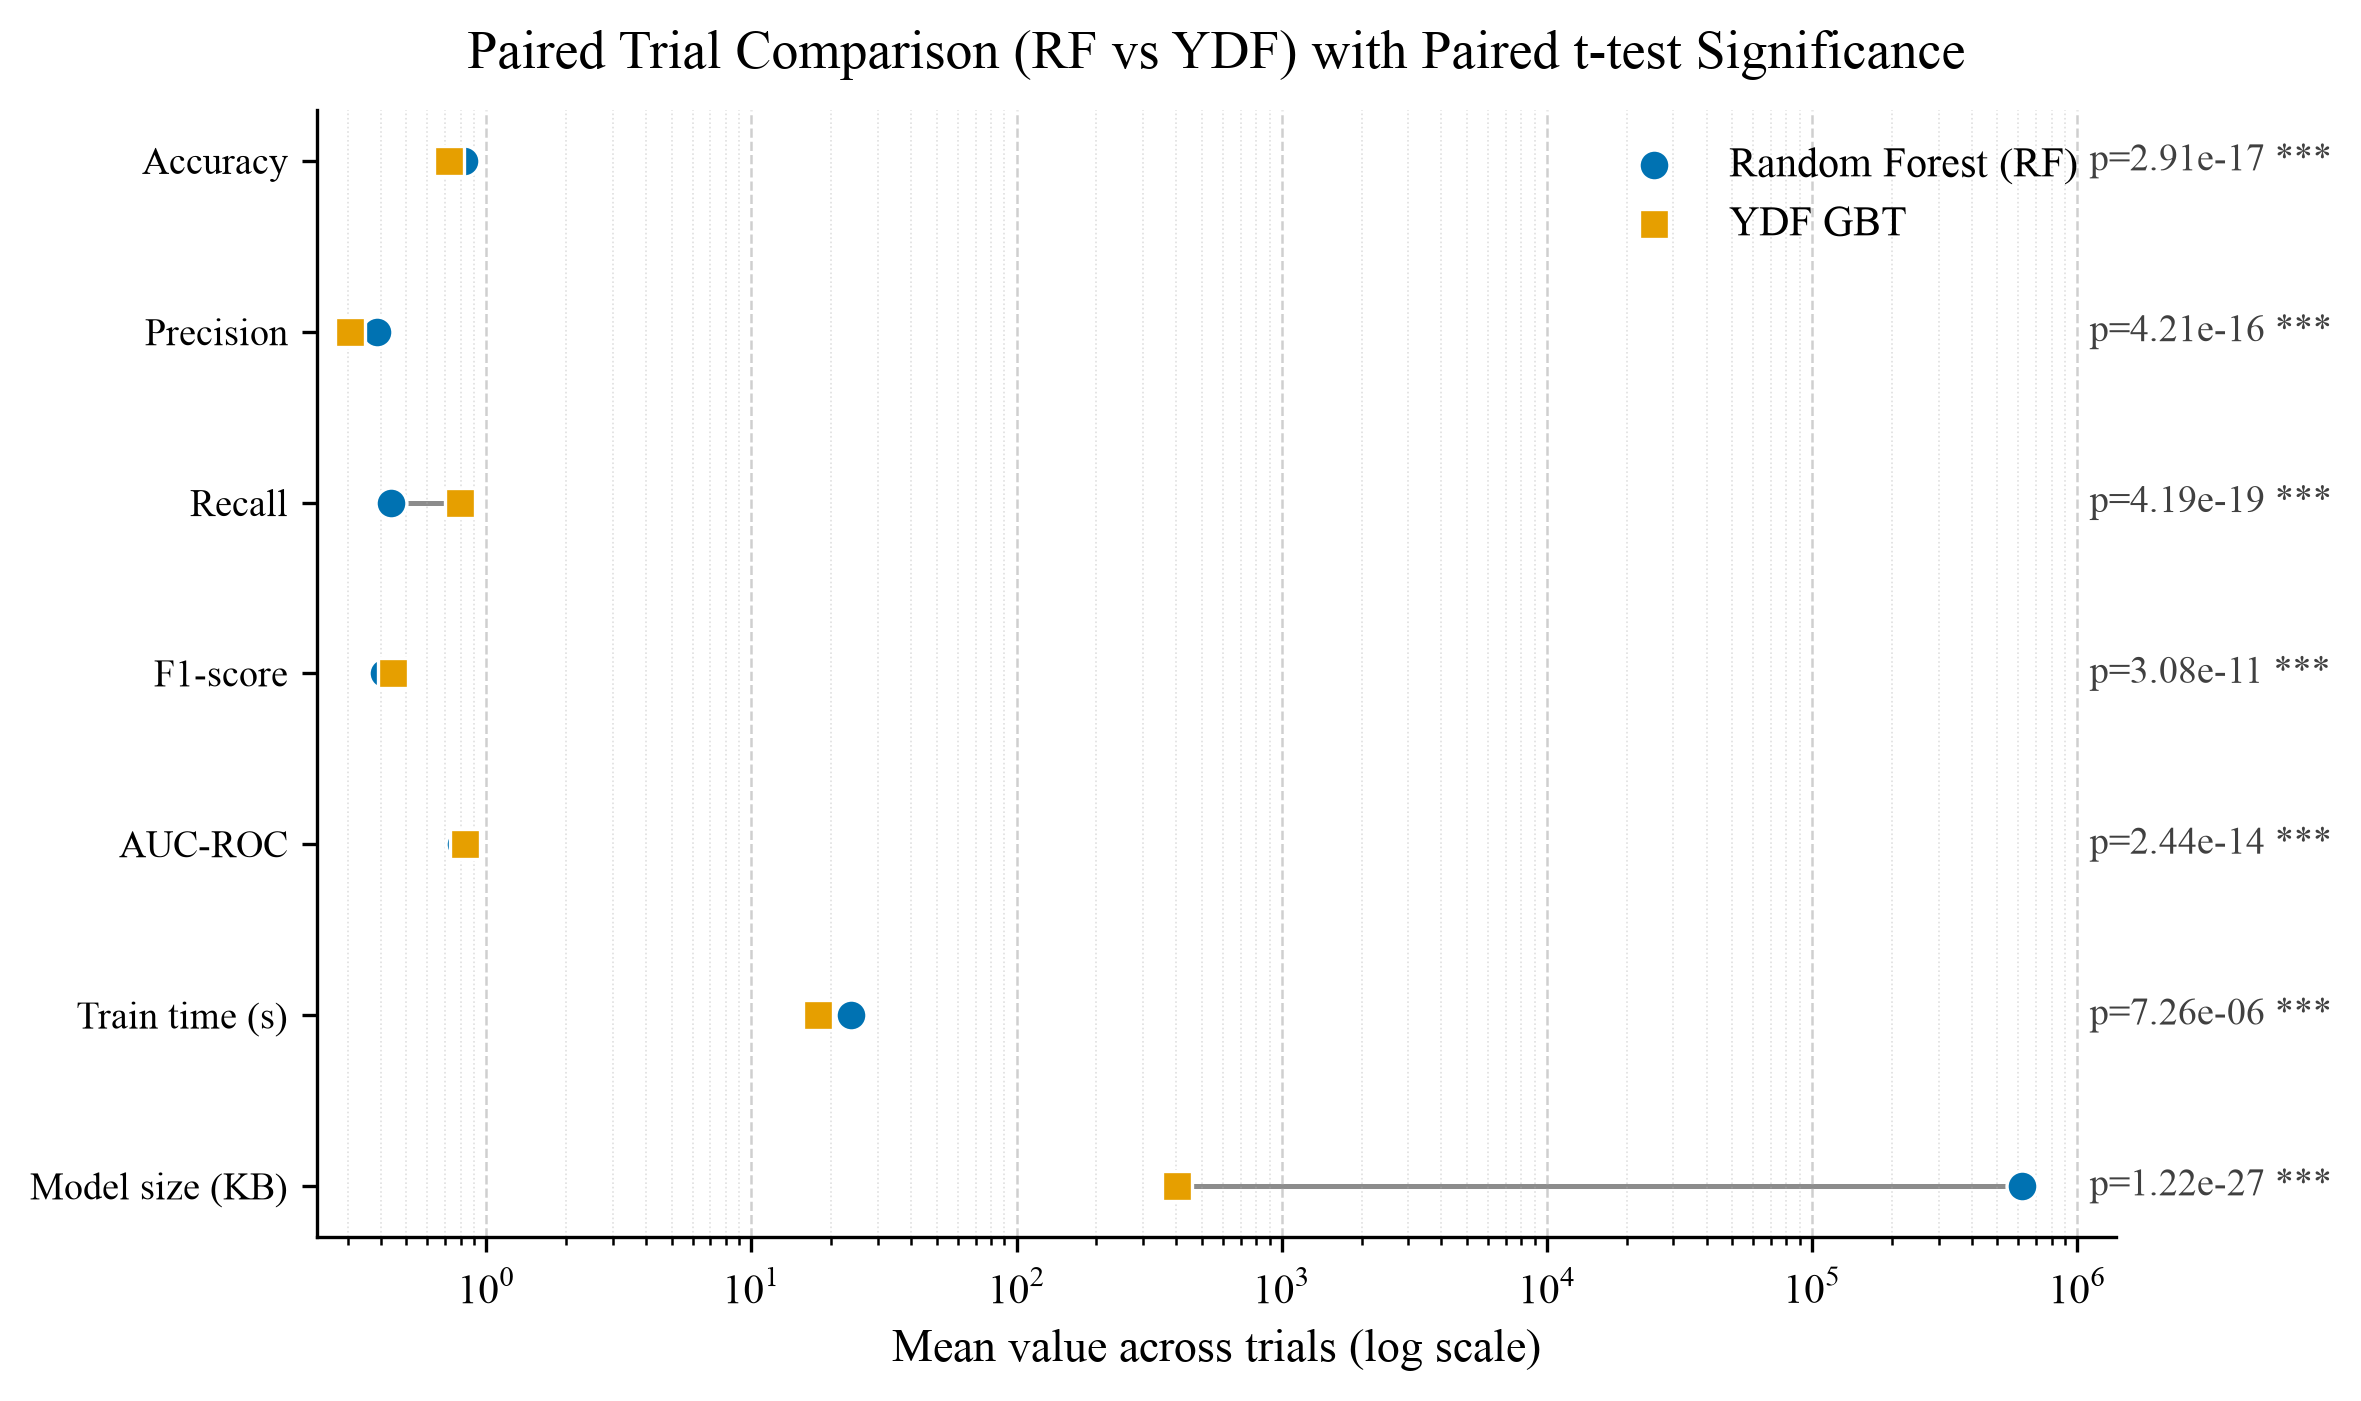

Saved → visualization/paired_ttest_rf_vs_ydf.pdf  &  visualization/paired_ttest_rf_vs_ydf.png


In [45]:
# Publication-grade paired t-test visualization (RF vs YDF) from ptt_results

metric_order = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "auc_roc",
    "train_time_s",
    "model_size_kb",
]

metric_labels = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
    "auc_roc": "AUC-ROC",
    "train_time_s": "Train time (s)",
    "model_size_kb": "Model size (KB)",
}

def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

plot_df = ptt_results.set_index("metric").loc[metric_order].copy()
ypos = np.arange(len(metric_order))[::-1]

rf_vals = plot_df["rf_mean"].to_numpy()
ydf_vals = plot_df["ydf_mean"].to_numpy()
pvals = plot_df["t_pvalue"].to_numpy()

fig, ax = plt.subplots(figsize=(8.0, 4.8))

# Connecting lines + markers
for i, y in enumerate(ypos):
    x1, x2 = rf_vals[i], ydf_vals[i]
    ax.plot([x1, x2], [y, y], color="0.55", linewidth=1.2, zorder=1)

ax.scatter(rf_vals, ypos, s=55, color=COLOR_RF, edgecolor="white", linewidth=0.8, label="Random Forest (RF)", zorder=3)
ax.scatter(ydf_vals, ypos, s=55, marker="s", color=COLOR_YDF, edgecolor="white", linewidth=0.8, label="YDF GBT", zorder=3)

# Axis formatting
ax.set_yticks(ypos)
ax.set_yticklabels([metric_labels[m] for m in metric_order])
ax.set_xscale("log")
ax.set_xlabel("Mean value across trials (log scale)")
ax.set_title("Paired Trial Comparison (RF vs YDF) with Paired t-test Significance", pad=10)

# Grid/spines
ax.grid(axis="x", which="major", linestyle="--", linewidth=0.6, alpha=0.6)
ax.grid(axis="x", which="minor", linestyle=":", linewidth=0.4, alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# p-value annotations
x_annot = max(rf_vals.max(), ydf_vals.max()) * 1.8
for i, y in enumerate(ypos):
    ax.text(
        x_annot,
        y,
        f"p={pvals[i]:.2e} {p_to_stars(pvals[i])}",
        va="center",
        ha="left",
        fontsize=9,
        color="0.25",
    )

xmin = min(rf_vals.min(), ydf_vals.min()) * 0.75
xmax = x_annot * 1.25
ax.set_xlim(xmin, xmax)

ax.legend(loc="upper right", frameon=False, framealpha=0.95, edgecolor="0.85")
plt.tight_layout()

out_path = Path("visualization/paired_ttest_rf_vs_ydf.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
# fig.savefig(out_path)
fig.savefig(out_path.with_suffix(".png"))
plt.show()

print(f"Saved → {out_path}  &  {out_path.with_suffix('.png')}")